# Parte 1
#### Miguel Pereira - Alejandro Gaona

En esta celda inicial preparamos el entorno de trabajo importando las herramientas.
Para el analisis:

* Pandas: Utilizada para la carga y manipulación del dataset de hongos.
* PGMPY: Librería para el modelado de las redes bayesianas. Importamos HillClimbSearch y ExhaustiveSearch para el aprendizaje de estructura, junto con los criterios de puntuación BIC y K2.
* Estimación e Inferencia: Cargamos **MaximumLikelihoodEstimator** para obtener las probabilidades condicionales y **VariableElimination** para realizar la inferencias a posteriori.
* Visualización: Empleamos **networkx** y **matplotlib** para representar gráficamente las dependencias encontradas por los algoritmos.


In [24]:
#bloque de imports de librerias DE LOS METODOS
import pandas as pd

from pgmpy.models import BayesianNetwork #la terminal me dijo que esta obsoleto
from pgmpy.estimators import HillClimbSearch, ExhaustiveSearch, BIC, K2

#los siguientes import son para estimar los parametros de la red bayesiana, es decir, para 
#aprender las probabilidades condicionales a partir de los datos, lo cual es un paso importante despues de haber aprendido la estructura de la red
from pgmpy.estimators import MaximumLikelihoodEstimator  # esto nos servira para estimar los parametros, tal como se enseña en la documentacion
from pgmpy.models import DiscreteBayesianNetwork

#los siguientes import son para poder hacer inferencias con la red bayesiana, 
#es decir, para poder hacer consultas sobre la red y obtener probabilidades de eventos dados ciertos evidencias
from pgmpy.example_models import load_model
from pgmpy.inference import VariableElimination

#import pgmpy.estimators
#print(dir(pgmpy.estimators))     # esto sirve para poder ver que clases y funciones tiene el modulo de estimadores de pgmpy, lo cual es util para saber que opciones tenemos

#imports de librerias para graficar

import networkx as nx
import matplotlib.pyplot as plt




Cargamos los datos y definimos las variables utiles a ocupar, para simplificar el analisis posterior se decidio utilizar 8 columnas en el Metodo de Hill-Climbing y 5 Columnas para Exhaustive-Search.

1. El descarte de columnas se hizo principalmente mediante el factor de analisis de que caracteristicas de los hongos hay que fijarnos principalmente para conocer la venocidad de un hongo. Para esto se leyeron multiples fuentes y la mas util fue: [Identificacion de hongos venenosos](https://bazarfungi.cl/blogs/noticias/identificar-hongos-venenosos), mediante la lectura pudimos descartar muchas columnas que no sirven para conocer si un hongo es venenoso o no.

2. Para la busqueda exhaustiva, simplemente se decidio el descarte de columnas por el factor de tiempo, ya que con 7 columnas se llego a tener un pick de t>30 min de procesamiento del algoritmo y aun asi no terminaba y con 6 columnas algo bastante parecido, por otro lado cuando se bajo una columnas más (5 columnas) el metodo termino en 2 min. lo cual nos beneficia bastante.

Links de ayuda para el descarte de columnas:
[web](https://www.iprofesional.com/salud/348972-hongo-comestible-como-identificarlo-y-evitar-intoxicaciones)
[web](https://www.wikibiologia.net/el-reino-fungi-caracteristicas-importancia-y-clasificacion-de-los-hongos/)

In [25]:
#cargado de datos y seleccion

#creamos un array con los nombres de las variables (columnas del archivo)
#como el archivo no viene con cabeceras este array servira para definirlas
# las definiciones de cada nombre de columna estan en la documentacion y se deben añadir en el informe
col_name = ['poisonuos', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 
           'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 
           'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 
           'stalk-surface-below-ring', 'stalk-color-above-ring', 
           'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 
           'ring-type', 'spore-print-color', 'population', 'habitat']

doc_completo = pd.read_csv('./mushroom/agaricus-lepiota.data', header=None, names=col_name)


HC_col_name = ['poisonuos', 'cap-shape', 'cap-color', 'odor', 
           'stalk-shape', 'stalk-root', 'veil-type', 'ring-type']

HC_doc = doc_completo[HC_col_name].copy() # aqui tenemos 7 columnas, se reducieron para que no sea un proceso tan pesadom ademas de poder analizar mejor los resultados

ES_col_name = ['poisonuos', 'cap-color', 'odor', 'stalk-root', 'veil-type']

#el copy() es mejor que hacer un script donde se guarden solo las columnas segun el nombre, asi es mas facil
ES_doc = doc_completo[ES_col_name].copy() # asi el doc solo tendra las columnas con ese nombre, en vez de meter todas en 5 o 7 columnas



# Aprendizaje para Hill-Climbing (HC)

Se implementa el algoritmo **HillClimbSearch** de la documentación, una técnica de búsqueda heurística local. Este comienza con una red vacía y realiza iteraciones añadiendo, eliminando o invirtiendo arcos para maximizar la puntuación del modelo.


**Metrica BIC :** Utilizamos BIC para evaluar la calidad de la red. Este criterio es muy importante porque penaliza la complejidad excesiva (evitando el sobreajuste), favoreciendo modelos que expliquen los datos con la menor cantidad de arcos posible.



In [26]:
hc = HillClimbSearch(HC_doc) #aplicamos el metodo HC para encontrar la estructura de la red bayesiana, el resultado se guarda en la variable hc
#este metodo se basa en una busqueda local que comienza con una estructura vacia
#  y va añadiendo, eliminando o revirtiendo arcos para mejorar la puntuacion del modelo segun el criterio de BIC

#obtenemos el mejor modelo encontrado por HC utilizando el criterio de BIC para evaluar la calidad del modelo
HC_mejor_modelo = hc.estimate(scoring_method=BIC(HC_doc))
#por ejemplo un resultado podria ser: (cap-shape, cap-color) lo que indica que hay un arco dirigido desde la variable cap-shape 
# hacia la variable cap-color, lo que sugiere que el color del sombrero puede depender de su forma

#los arcos encontrados por HC representan las relaciones de dependencia entre las variables del conjunto de datos
print("Arcos encontrados: ")
print(HC_mejor_modelo.edges())


C:\Users\mike\AppData\Local\Temp\ipykernel_20796\231762910.py:1: FutureWarning: HillClimbSearch is deprecated. Please use pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(HC_doc) #aplicamos el metodo HC para encontrar la estructura de la red bayesiana, el resultado se guarda en la variable hc
  0%|          | 11/1000000 [00:00<12:07:38, 22.90it/s]

Arcos encontrados: 
[('poisonuos', 'odor'), ('poisonuos', 'cap-shape'), ('odor', 'stalk-root'), ('odor', 'ring-type'), ('odor', 'cap-color'), ('odor', 'stalk-shape'), ('stalk-shape', 'stalk-root'), ('stalk-shape', 'cap-color'), ('stalk-root', 'cap-shape'), ('ring-type', 'stalk-shape'), ('ring-type', 'stalk-root')]


# Aprendizaje para Exhaustive Search (ES)

A diferencia del método anterior, la Búsqueda Exhaustiva garantiza encontrar la estructura óptima global al evaluar todas las combinaciones posibles de grafos (DAGs).

**Metrica K2:** Para este método empleamos la puntuación K2, un criterio bayesiano que busca maximizar la probabilidad de la estructura dados los datos observados. Debido a que este algoritmo revisa cada posibilidad, el tiempo de procesamiento es crítico, justificando con esto que hayamos reducido a 5 variables previamente.

In [4]:
#definir el metodo de puntuación
puntuacion = K2(ES_doc)

#pasar la puntuación AL CONSTRUCTOR del objeto ExhaustiveSearch
est = ExhaustiveSearch(ES_doc, scoring_method=puntuacion)

#ejecutar el .estimate()
ES_mejor_modelo = est.estimate()

print("Arcos encontrados por E_S:")
print(ES_mejor_modelo.edges())

Arcos encontrados por E_S:
[('odor', 'cap-color'), ('odor', 'poisonuos'), ('odor', 'stalk-root'), ('poisonuos', 'cap-color'), ('poisonuos', 'stalk-root'), ('stalk-root', 'cap-color'), ('veil-type', 'poisonuos')]


# Graficos HC

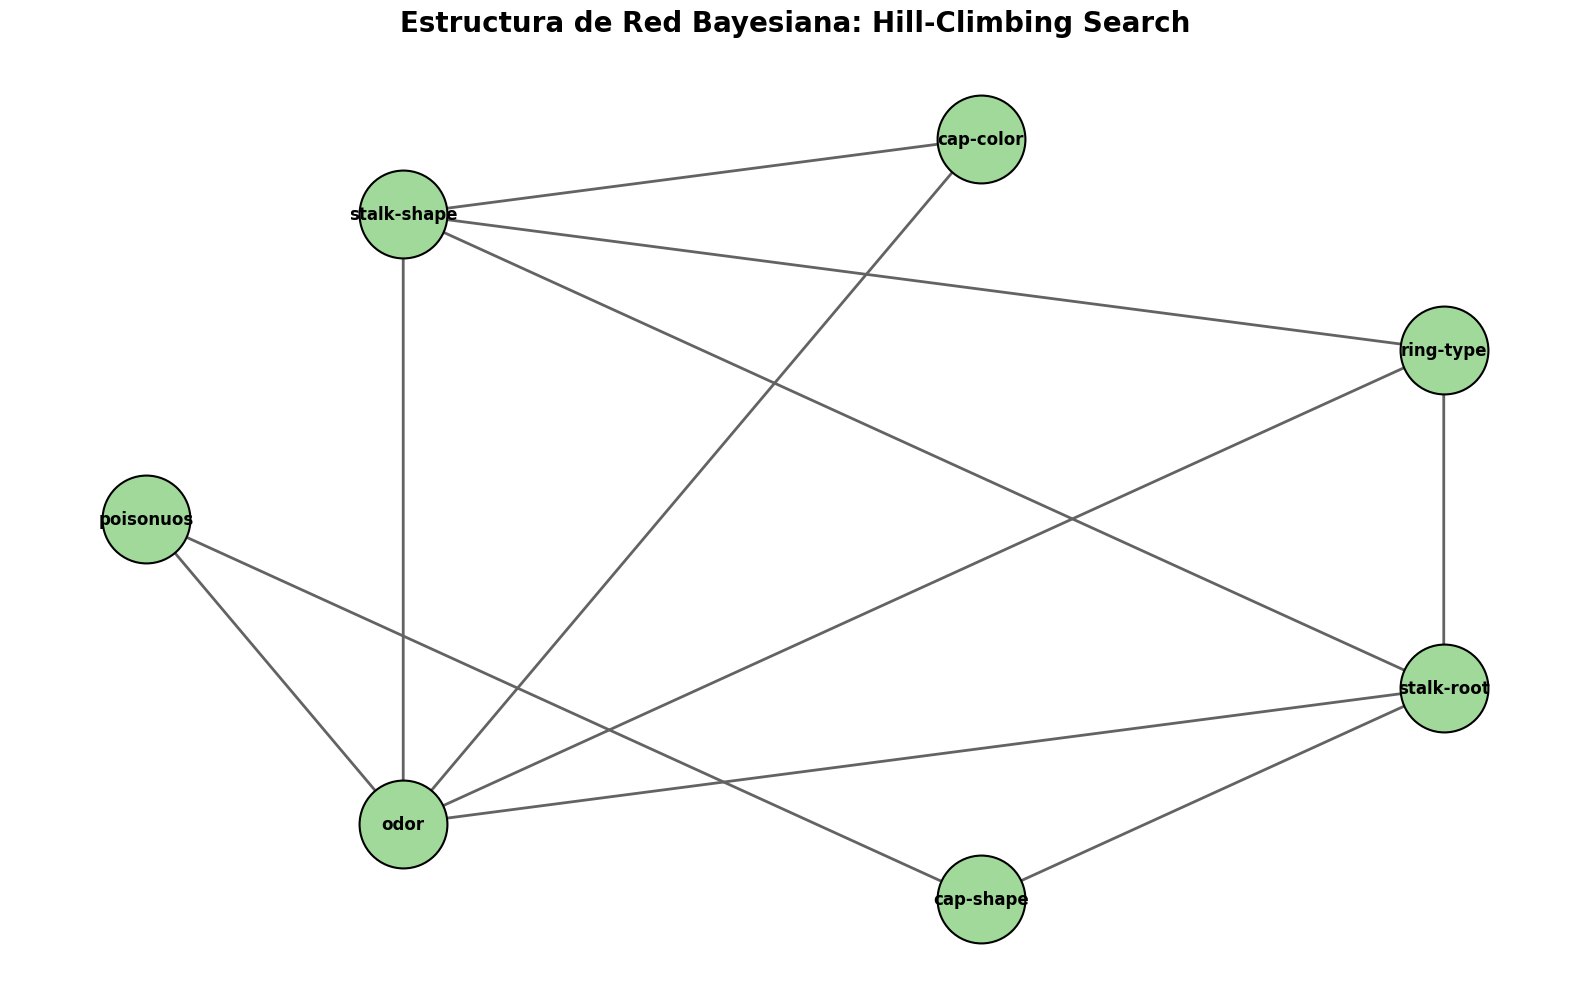

In [27]:
modelo_a_graficar = HC_mejor_modelo 

# Convertimos los arcos aprendidos en un Grafo Dirigido de NetworkX
G_hc = nx.DiGraph(modelo_a_graficar.edges())

# --- ESTILO Y DISEÑO (AQUÍ ESTÁ LO "BONITO") ---
plt.figure(figsize=(16, 10)) # Tamaño grande para que se lea bien

# Diseño: Usamos 'shell_layout' para organizar los nodos en círculos concéntricos
# Esto ordena mucho la vista cuando hay muchas variables.
pos_hc = nx.shell_layout(G_hc)

# 1. Dibujar los Nodos (Círculos)
nx.draw_networkx_nodes(G_hc, pos_hc, 
                       node_size=4000,          # Tamaño grande
                       node_color='#a1d99b',    # Verde suave (estilo hongos)
                       edgecolors='black',      # Borde negro fino
                       linewidths=1.5)

# 2. Dibujar los Arcos (Flechas)
nx.draw_networkx_edges(G_hc, pos_hc, 
                       edgelist=G_hc.edges(),
                       edge_color='#636363',    # Gris oscuro
                       arrowsize=25,            # Flechas grandes y visibles
                       arrowstyle='->',        # Estilo de flecha limpia
                       width=2.0)               # Grosor de la línea

# 3. Dibujar las Etiquetas (Nombres de variables)
nx.draw_networkx_labels(G_hc, pos_hc, 
                        font_size=12, 
                        font_family='sans-serif', 
                        font_weight='bold')

plt.title("Estructura de Red Bayesiana: Hill-Climbing Search", fontsize=20, fontweight='bold', pad=20)
plt.axis('off') # Ocultar los ejes cartesianos
plt.tight_layout() # Ajustar márgenes automáticamente
plt.show()

### Resultados HC

Como se puede apreciar HC aprendio la estructura ingresada del dataset y aunque se inicio con 8 columnas utiles, solo se obtienen 7 nodos como se puede ver en la grafica, esto sucede debido a que el metodo de puntuación BIC es un juez muy estricto y "minimalista". Su prioridad es evitar el sobreajuste, por lo que si una variable como veil-type no aporta información estadística útil, prefiere dejarla aislada para mantener el modelo simple. (en el dataset veil-type casi siempre en 'p')

# Graficos ES

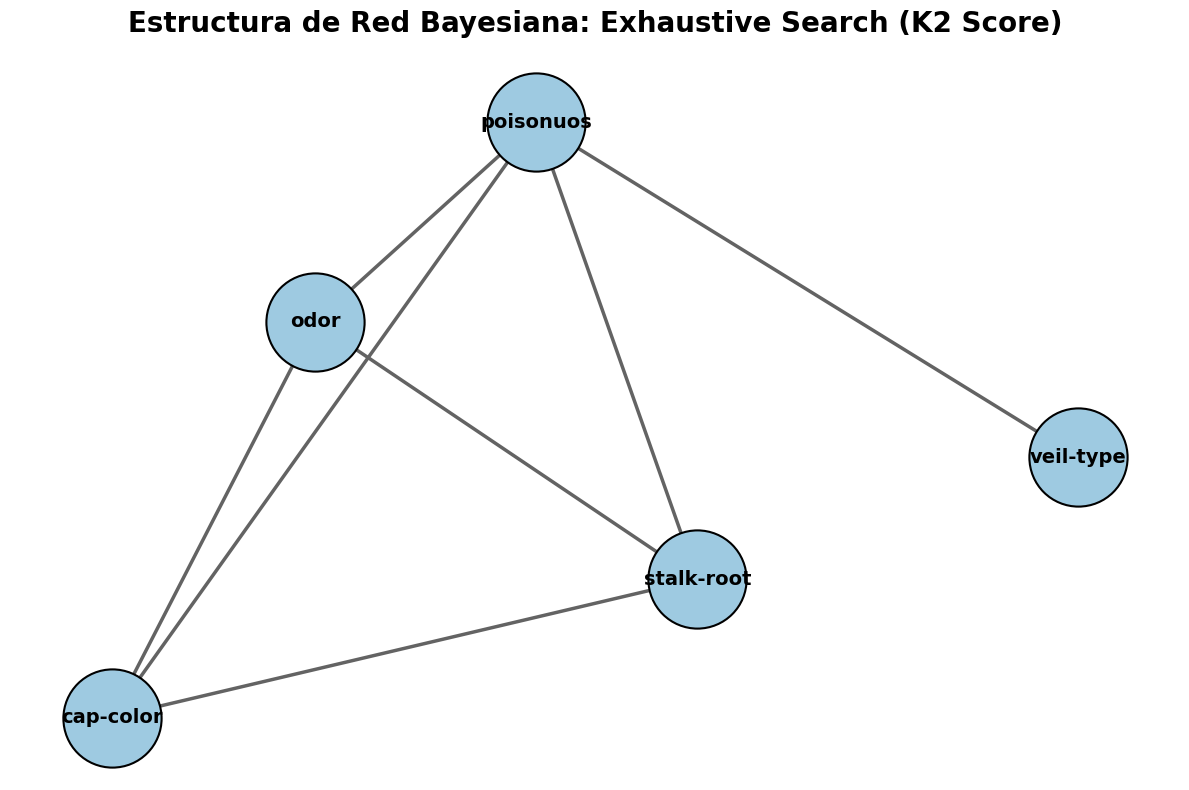

In [28]:
modelo_es_a_graficar = ES_mejor_modelo

G_es = nx.DiGraph(modelo_es_a_graficar.edges())

# Si el modelo no encontró arcos (grafo vacío), avisamos para no dar error
if G_es.number_of_edges() == 0:
    print("El modelo de Búsqueda Exhaustiva no encontró ninguna conexión significativa (arcos).")
    # Dibujamos solo los nodos sueltos para que no quede en blanco
    G_es.add_nodes_from(modelo_es_a_graficar.nodes()) 

plt.figure(figsize=(12, 8)) # Un poco más pequeño porque hay menos nodos

# Diseño: Usamos 'spring_layout' que separa los nodos como si fueran imanes.
# Es ideal para ver estructuras claras en grafos pequeños.
pos_es = nx.spring_layout(G_es, k=1.0, iterations=50)

# 1. Dibujar los Nodos
nx.draw_networkx_nodes(G_es, pos_es, 
                       node_size=5000,          # Nodos aún más grandes
                       node_color='#9ecae1',    # Azul suave
                       edgecolors='black', 
                       linewidths=1.5)

# 2. Dibujar los Arcos (con K2 Score)
nx.draw_networkx_edges(G_es, pos_es, 
                       edgelist=G_es.edges(),
                       edge_color='#636363', 
                       arrowsize=30,            # Flechas extra grandes
                       arrowstyle='->',
                       arrows = True,
                       width=2.5)               # Líneas más gruesas

# 3. Dibujar las Etiquetas
nx.draw_networkx_labels(G_es, pos_es, 
                        font_size=14, 
                        font_family='sans-serif', 
                        font_weight='bold')

# --- FINALIZAR ---
plt.title("Estructura de Red Bayesiana: Exhaustive Search (K2 Score)", fontsize=20, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

## Resultados ES

La estructura obtenida mediante Exhaustive Search con el criterio K2 revela una red de dependencias densa, donde la variable odor se consolida como el nodo raíz principal que influye directamente en la toxicidad (poisonuos), la raíz del tallo (stalk-root) y el color del sombrero (cap-color). A diferencia del método Hill-Climbing, la búsqueda exhaustiva logra conectar la variable veil-type a la red, lo que demuestra la alta sensibilidad del algoritmo K2 para capturar incluso relaciones estadísticas mínimas que otros criterios más restrictivos como BIC suelen omitir por falta de varianza.

### Grafico ejemplo de HC con flechas de dirección

In [ ]:
# 1. Crear un objeto de dibujo con la estructura aprendida
# (Suponiendo que tu modelo se llama 'mejor_modelo_hc')
model_graph = nx.DiGraph(HC_mejor_modelo.edges())

# 2. Configurar el diseño (layout) y el tamaño de la figura
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(model_graph, k=0.5) # Ajusta 'k' para separar más los nodos

# 3. Dibujar nodos, flechas y etiquetas
nx.draw(model_graph, pos, with_labels=True, node_size=3000, 
        node_color="skyblue", font_size=10, font_weight="bold", 
        arrowsize=20, edge_color="gray")

plt.title("Estructura de la Red Bayesiana (Hill-Climbing)")
plt.show()

# Estimación de parametros (CPDs)
Una vez obtenidas las estructuras (los arcos), procedemos a "entrenar" la red mediante la estimación de parámetros. Utilizamos el **MaximumLikelihoodEstimator** (Estimador de Máxima Verosimilitud), que calcula las tablas de probabilidad condicional contando las frecuencias de aparición de cada estado en el dataset. Estas tablas representan numéricamente la influencia de una variable sobre otra (por ejemplo, cómo el olor determina la probabilidad de ser venenoso).

In [29]:
HC_modelo_final = DiscreteBayesianNetwork(HC_mejor_modelo.edges()) # tengo que ver bien que wea hace esto porque solo copie y pegue esto de la documentacion
ES_modelo_final = DiscreteBayesianNetwork(ES_mejor_modelo.edges())

#aqui hacemos la estimacion de parametros
HC_modelo_final.fit(HC_doc, estimator=MaximumLikelihoodEstimator)
ES_modelo_final.fit(ES_doc, estimator=MaximumLikelihoodEstimator)


HC_modelo_final.cpds
ES_modelo_final.cpds


# Mostrar CPDs de forma legible
#print("\n--- Parámetros de la red (CPDs) ---")
for cpd in HC_modelo_final.get_cpds():
    print(cpd)

for cpd in ES_modelo_final.get_cpds():
    print(cpd)


+--------------+----------+
| poisonuos(e) | 0.517971 |
+--------------+----------+
| poisonuos(p) | 0.482029 |
+--------------+----------+
+-----------+---------------------+----------------------+
| poisonuos | poisonuos(e)        | poisonuos(p)         |
+-----------+---------------------+----------------------+
| odor(a)   | 0.09505703422053231 | 0.0                  |
+-----------+---------------------+----------------------+
| odor(c)   | 0.0                 | 0.049029622063329927 |
+-----------+---------------------+----------------------+
| odor(f)   | 0.0                 | 0.5515832482124617   |
+-----------+---------------------+----------------------+
| odor(l)   | 0.09505703422053231 | 0.0                  |
+-----------+---------------------+----------------------+
| odor(m)   | 0.0                 | 0.009193054136874362 |
+-----------+---------------------+----------------------+
| odor(n)   | 0.8098859315589354  | 0.030643513789581207 |
+-----------+---------------------

# Inferencias a Posteriori

Para validar la utilidad del modelo, realizamos consultas de tipo diagnóstico utilizando el algoritmo de **Eliminación de Variables**. Este método optimiza el cálculo de probabilidades marginales eliminando de la ecuación aquellas variables que no participan en la consulta mediante la suma de sus probabilidades.

* **Consulta 1:** Cual es la probabilidad de que sea venenoso dado que [cap-shape: convex] y el [odor: pungent] 
* **Consulta 2:** Cual es la probabilidad de que sea venenoso dado que [cap-color: brown] y el olor picante [odor: pungent]

In [30]:
#inferencias a posteriori 1 (diagnostico) (Hill-Climbing)

HC_inferencia = VariableElimination(HC_modelo_final)

#cual es la probabilidad de que sea venenoso dado que [cap-shape: convex] y el [odor: pungent] 
HC_resultado1 = HC_inferencia.query(variables=["poisonuos"], evidence={"cap-shape": "x" , "odor": "p"},)

#
HC_resultado2 = HC_inferencia.query(variables=["poisonuos"], evidence={"cap-color": "n" , "odor": "p"},)


#https://pgmpy.org/started/quickstart.html#quickstart-parameter-estimation
print("Resultados de inferencia para HC 1 original:")
print(HC_resultado1)
print("\n")

print("Resultados de inferencia para HC 2 original:")
print(HC_resultado2)

Resultados de inferencia para HC 1 original:
+--------------+------------------+
| poisonuos    |   phi(poisonuos) |
+==============+==================+
| poisonuos(e) |           0.0000 |
+--------------+------------------+
| poisonuos(p) |           1.0000 |
+--------------+------------------+


Resultados de inferencia para HC 2 original:
+--------------+------------------+
| poisonuos    |   phi(poisonuos) |
+==============+==================+
| poisonuos(e) |           0.0000 |
+--------------+------------------+
| poisonuos(p) |           1.0000 |
+--------------+------------------+


In [31]:
#inferencias a posteriori 2 (diagnostico) (Exhaustive Search)
ES_inferencia = VariableElimination(ES_modelo_final)

#cual es la probabilidad de que sea venenoso dado que [cap-color: n] y el [odor: pungent]
ES_ressultado1 = ES_inferencia.query(variables=["poisonuos"], evidence={"cap-color": "n" , "odor": "p"},)

#cual es la probabilidad de que sea venenoso dado que [stalk-root: b] y el [veil-type: p]
ES_resultado2 = ES_inferencia.query(variables=["poisonuos"], evidence={"stalk-root": "b" , "veil-type": "p"},)  

print("Resultados de inferencia para E_S 1 original:")
print(ES_ressultado1)
print("\n")

print("Resultados de inferencia para E_S 2 original:")
print(ES_resultado2)


Resultados de inferencia para E_S 1 original:
+--------------+------------------+
| poisonuos    |   phi(poisonuos) |
+==============+==================+
| poisonuos(e) |           0.0000 |
+--------------+------------------+
| poisonuos(p) |           1.0000 |
+--------------+------------------+


Resultados de inferencia para E_S 2 original:
+--------------+------------------+
| poisonuos    |   phi(poisonuos) |
+==============+==================+
| poisonuos(e) |           0.5085 |
+--------------+------------------+
| poisonuos(p) |           0.4915 |
+--------------+------------------+


# Generación y Analisis de datos sintéticos 

SIguiendo los requerimientos y la documentación, se utiliza el método .simulate() para generar muestras nuevas basadas en la distribución aprendida por la red original.

* **Aumento del Dataset**: Se crean tres nuevos conjuntos de datos incrementando el tamaño original en un 10%, 20% y 40%.
* **Comparativa de Robustez:** Para cada dataset aumentado, se repite el flujo completo (Estructura -> Parámetros -> Inferencia). El objetivo es analizar si la red se mantiene estable o si la introducción de datos sintéticos refuerza las dependencias encontradas inicialmente, evaluando la capacidad de generalización del modelo ante una mayor cantidad de muestras.

## No ejecutar la siguiente celda
sirvio para generar los datos sinteticos, pero los genera con cabecera y por tanto el resto de codigo tendra error ya que si ejecuta volveran a cargar los archivos pero tendran cabeceras. Los datos sinteticos creados con 10%, 20% y 40% ya se encuentran en la carpeta ./mushroom

In [48]:
# ahora hay que hacer la generacion de datos sinteticos a partir de las redes bayesianas aprendidas, 
# esto se hace para poder evaluar el rendimiento de las redes en tareas de inferencia y diagnostico, 
# ademas de poder comparar los resultados con los datos reales y ver si las redes son capaces de generalizar bien a nuevos casos. 
# Para esto se pueden usar funciones como 
# 'sample' que permiten generar muestras sintéticas a partir de la distribución aprendida por la red bayesiana.

#ejemplo para el 10% de aumento
#se hace con el modelo de HC porque este el docuemtno mas grande que trabajaremos entonces
n_original = len(HC_doc) # obtenemos el numero de muestras originales del dataset para poder calcular el 10%
n_extra_10 = int(n_original * 0.10)
n_extra_20 = int(n_original * 0.20)
n_extra_40 = int(n_original * 0.40)

#aqui se hace esto porque asi podemos generar datos sinteticos a partir del dataset original y de la estructura aprendida por la red bayesiana,
# lo cual es importante para poder evaluar el rendimiento de la red en tareas de inferencia y diagnostico, 
# ademas de poder comparar los resultados con los datos reales y ver si las redes son capaces de generalizar bien a nuevos casos.
# ya que si solo lo hacmeos de la red aprendida la columna veil-type no va a tener datos sinteticos porque no tiene arcos, 
# entonces al hacer esto se asegura que todas las columnas tengan datos sinteticos generados a partir de la red bayesiana aprendida, 
# lo cual es importante para poder evaluar el rendimiento de la red en tareas de inferencia y diagnostico, ademas de que ES si la va a necesitar
HC_modelo_final.add_nodes_from(HC_doc.columns)
HC_modelo_final.fit(HC_doc, estimator=MaximumLikelihoodEstimator)

df_sintetico_10_c1= HC_modelo_final.simulate(n_samples=n_extra_10)
df_sintetico_20_c2= HC_modelo_final.simulate(n_samples=n_extra_20)
df_sintetico_40_c3 = HC_modelo_final.simulate(n_samples=n_extra_40)


#unimos los datos sinteticos generado al dataset original para crear el "Dataset Aumentado"
df_aumentado_10_c1= pd.concat([HC_doc, df_sintetico_10_c1], ignore_index=True)
df_aumentado_20_c2= pd.concat([HC_doc, df_sintetico_20_c2], ignore_index=True)
df_aumentado_40_c3 = pd.concat([HC_doc, df_sintetico_40_c3], ignore_index=True)


df_aumentado_10_c1.to_csv('./mushroom/df_aumentado_10_c1.csv', index=False, header=False)
df_aumentado_20_c2.to_csv('./mushroom/df_aumentado_20_c2.csv', index=False, header=False)
df_aumentado_40_c3.to_csv('./mushroom/df_aumentado_40_c3.csv', index=False, header=False)




#https://pgmpy.org/guides/simulations.html
#https://pgmpy.org/started/quickstart.html#quickstart-parameter-estimation

Generating for node: cap-shape: 100%|██████████| 8/8 [00:00<00:00, 104.43it/s]


## PARA HILL-CLIMBING : Cargado de datos (hc y es) -> Aprendizaje de estructura -> Graficos

aqui primero cargamos los datos borrando las cabeceras de los archivos generados debido a que como ya tenemos codigo arriba listo que nos servira es mejor tambien trabajar con los datos sin cabecera, asi no creamos codigo nuevo. Entonces despues de borrar las cabeceras de los archivos aumentados, volvemos a crear las varibles que nos seran utiles

In [33]:
"""
PARA HILL-CLIMBING

ahora despues de generar los datos sinteticos, tenemos que hacer lo mismo que antes, osea aprender la estrctura bayesiana 
con los metodos de Hill-Climbing y Exhaustive Search, pero esta vez con los datasets aumentados, para poder 
comparar los resultados con los datos reales y ver si las redes son capaces de generalizar bien a nuevos casos

"""
# col_name = ['poisonuos', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 
#            'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 
#            'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 
#            'stalk-surface-below-ring', 'stalk-color-above-ring', 
#            'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 
#            'ring-type', 'spore-print-color', 'population', 'habitat']

#HC_col_name = ['poisonuos', 'cap-shape', 'cap-color', 'odor', 
#           'stalk-shape', 'stalk-root', 'veil-type', 'ring

#ES_col_name = ['poisonuos', 'cap-color', 'odor', 'stalk-root', 'veil-type']


#leemos los datos aumentados, estos serian los datos completos, como antes lo teniamos "doc_completo"
df_aumentado_10 = pd.read_csv('./mushroom/df_aumentado_10_c1.csv', header=None, names=HC_col_name)
df_aumentado_20 = pd.read_csv('./mushroom/df_aumentado_20_c2.csv', header=None, names=HC_col_name)
df_aumentado_40 = pd.read_csv('./mushroom/df_aumentado_40_c3.csv', header=None, names=HC_col_name)


HC_doc_10 = df_aumentado_10.copy() # aqui tenemos las 23 columnas
HC_doc_20 = df_aumentado_20.copy() # aqui tenemos las 23 columnas
HC_doc_40 = df_aumentado_40.copy() # aqui tenemos las 23 columnas

#el copy() es mejor que hacer un script donde se guarden solo las columnas segun el nombre, asi es mas facil
ES_doc_10= df_aumentado_10[ES_col_name].copy()
ES_doc_20= df_aumentado_20[ES_col_name].copy()
ES_doc_40= df_aumentado_40[ES_col_name].copy()



hc_10 = HillClimbSearch(HC_doc_10) 
hc_20 = HillClimbSearch(HC_doc_20)
hc_40 = HillClimbSearch(HC_doc_40)

HC_mejor_modelo_10 = hc_10.estimate(scoring_method=BIC(HC_doc_10))
HC_mejor_modelo_20 = hc_20.estimate(scoring_method=BIC(HC_doc_20))
HC_mejor_modelo_40 = hc_40.estimate(scoring_method=BIC(HC_doc_40))

print("Arcos encontrados 10: ")
print(HC_mejor_modelo_10.edges())

print("Arcos encontrados 20: ")
print(HC_mejor_modelo_20.edges())

print("Arcos encontrados 40: ")
print(HC_mejor_modelo_40.edges())





C:\Users\mike\AppData\Local\Temp\ipykernel_20796\2122705817.py:39: FutureWarning: HillClimbSearch is deprecated. Please use pgmpy.causal_discovery.HillClimbSearch instead.
  hc_10 = HillClimbSearch(HC_doc_10)
C:\Users\mike\AppData\Local\Temp\ipykernel_20796\2122705817.py:40: FutureWarning: HillClimbSearch is deprecated. Please use pgmpy.causal_discovery.HillClimbSearch instead.
  hc_20 = HillClimbSearch(HC_doc_20)
C:\Users\mike\AppData\Local\Temp\ipykernel_20796\2122705817.py:41: FutureWarning: HillClimbSearch is deprecated. Please use pgmpy.causal_discovery.HillClimbSearch instead.
  hc_40 = HillClimbSearch(HC_doc_40)
  0%|          | 11/1000000 [00:00<9:11:24, 30.22it/s]

Arcos encontrados 10: 
[('poisonuos', 'odor'), ('poisonuos', 'cap-shape'), ('odor', 'stalk-root'), ('odor', 'ring-type'), ('odor', 'cap-color'), ('odor', 'stalk-shape'), ('stalk-shape', 'stalk-root'), ('stalk-shape', 'cap-color'), ('stalk-root', 'cap-shape'), ('ring-type', 'stalk-shape'), ('ring-type', 'stalk-root')]
Arcos encontrados 20: 
[('poisonuos', 'odor'), ('poisonuos', 'cap-shape'), ('cap-color', 'stalk-shape'), ('odor', 'stalk-root'), ('odor', 'ring-type'), ('odor', 'cap-color'), ('odor', 'stalk-shape'), ('stalk-shape', 'stalk-root'), ('stalk-shape', 'ring-type'), ('stalk-root', 'ring-type'), ('stalk-root', 'cap-shape')]
Arcos encontrados 40: 
[('poisonuos', 'odor'), ('poisonuos', 'cap-shape'), ('cap-color', 'stalk-shape'), ('odor', 'stalk-root'), ('odor', 'ring-type'), ('odor', 'cap-color'), ('odor', 'stalk-shape'), ('stalk-shape', 'stalk-root'), ('stalk-shape', 'ring-type'), ('stalk-root', 'ring-type'), ('stalk-root', 'cap-shape')]


### Graficos de HC con 10% de datos sinteticos aumentado

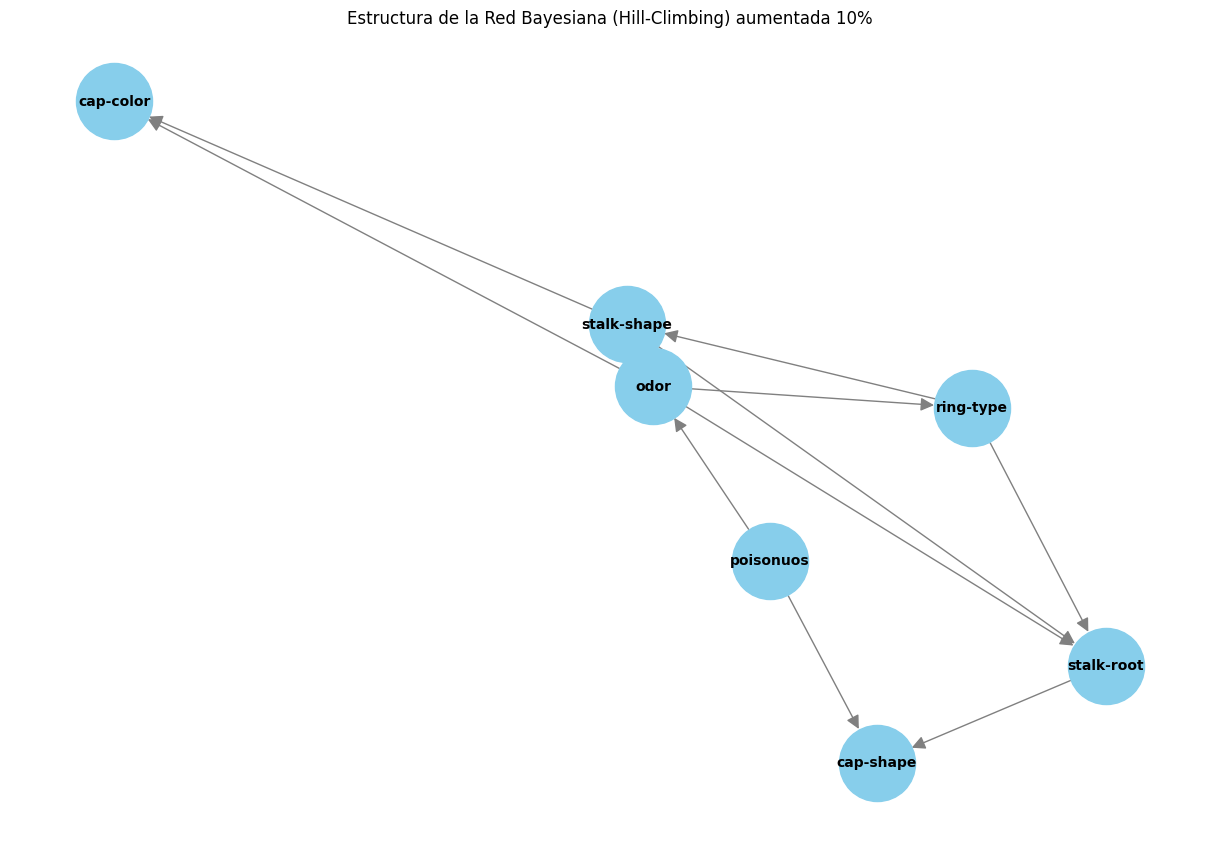

In [34]:
#PARA HILL-CLIMBING
#Ahora graficaremos las estructuras aprendiadas por HC

model_graph_10= nx.DiGraph(HC_mejor_modelo_10.edges())

plt.figure(figsize=(12, 8))
pos_10= nx.spring_layout(model_graph_10, k=0.5)

nx.draw(model_graph_10, pos_10, with_labels=True, node_size=3000, 
        node_color="skyblue", font_size=10, font_weight="bold", 
        arrowsize=20, edge_color="gray")


plt.title("Estructura de la Red Bayesiana (Hill-Climbing) aumentada 10%")
plt.show()





### Graficos de HC con 20% de datos sinteticos aumentado

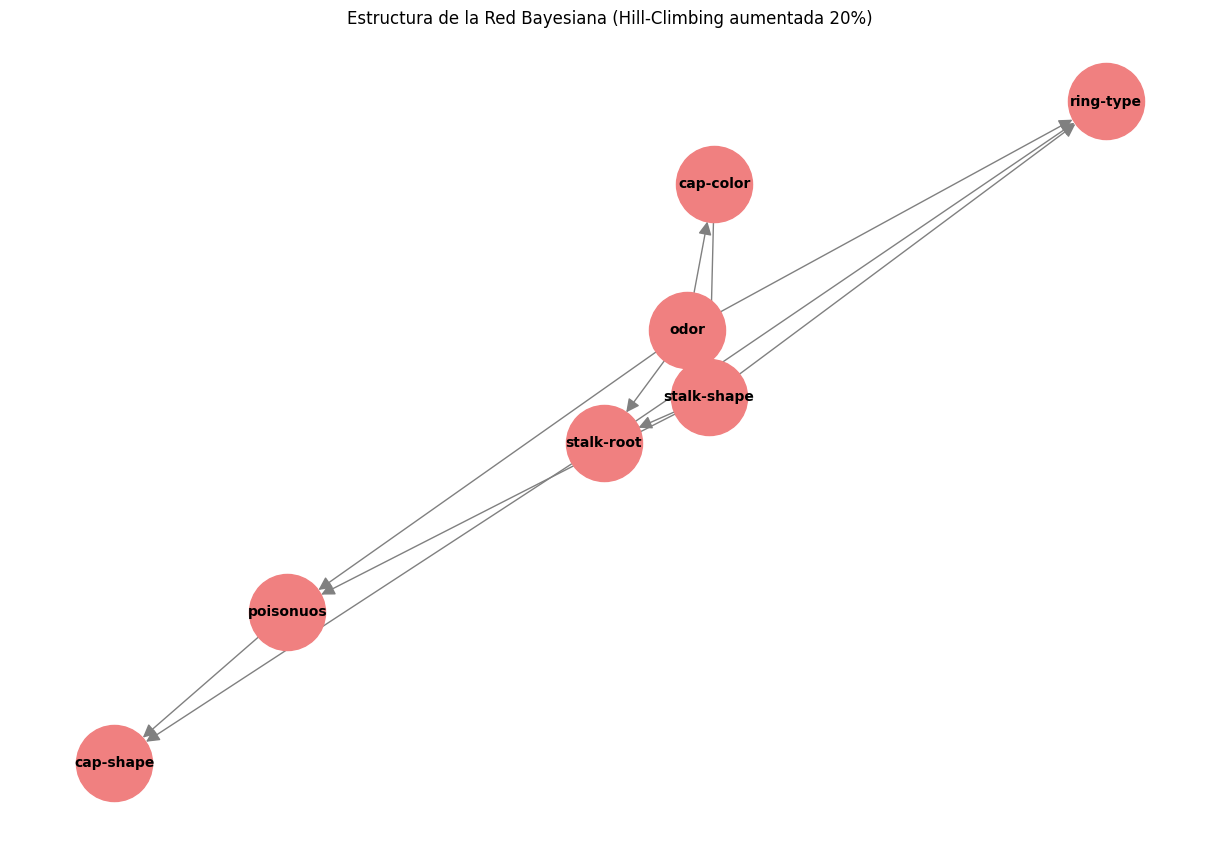

In [13]:
model_graph_20= nx.DiGraph(HC_mejor_modelo_20.edges())
plt.figure(figsize=(12, 8))
pos_20 = nx.spring_layout(model_graph_20, k=0.5)
nx.draw(model_graph_20, pos_20, with_labels=True, node_size=3000, 
        node_color="lightcoral", font_size=10, font_weight="bold", 
        arrowsize=20, edge_color="gray")

plt.title("Estructura de la Red Bayesiana (Hill-Climbing aumentada 20%)")
plt.show()

### Graficos de HC con 40% de datos sinteticos aumentado

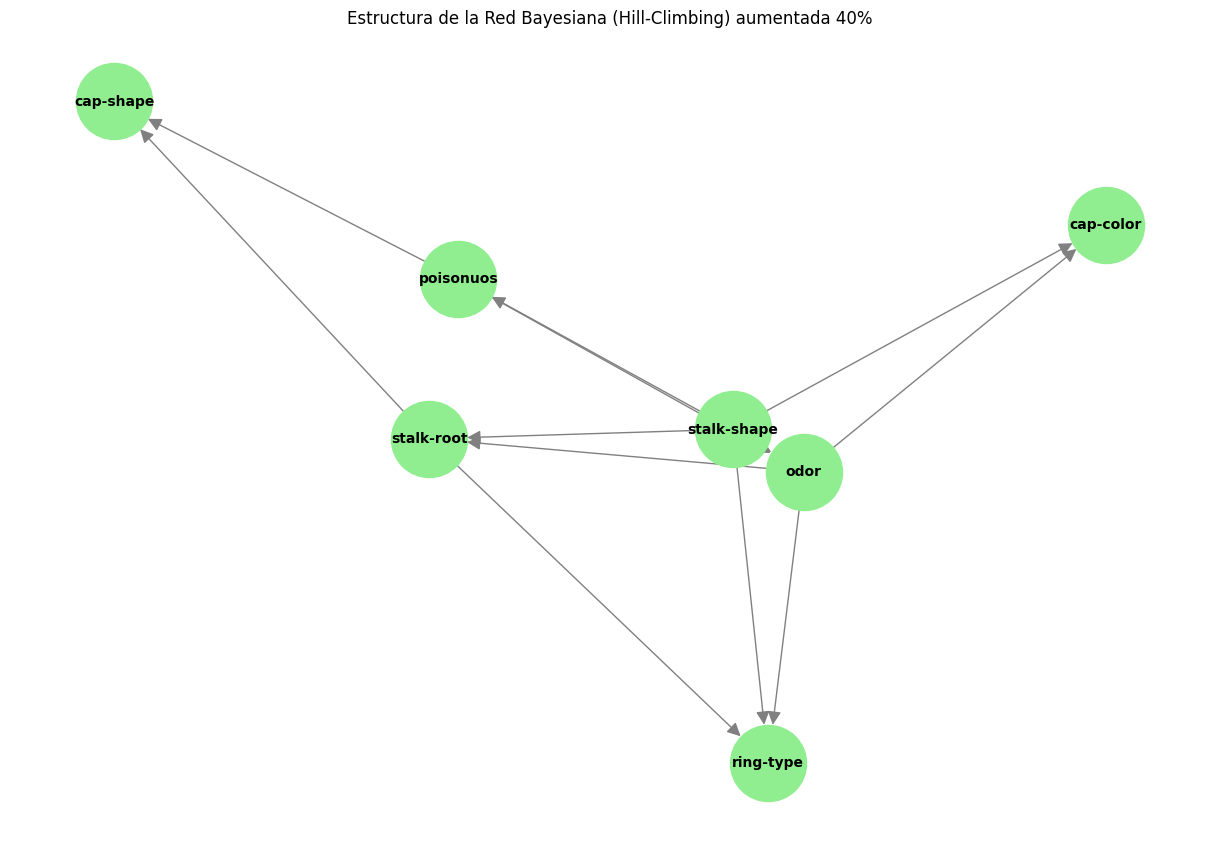

In [14]:
model_graph_40= nx.DiGraph(HC_mejor_modelo_40.edges())
plt.figure(figsize=(12, 8))
pos_40 = nx.spring_layout(model_graph_40, k=0.5)
nx.draw(model_graph_40, pos_40, with_labels=True, node_size=3000, 
        node_color="lightgreen", font_size=10, font_weight="bold", 
        arrowsize=20, edge_color="gray")

plt.title("Estructura de la Red Bayesiana (Hill-Climbing) aumentada 40%")
plt.show()

## HC : Estimación de parametros con 10% de datos sinteticos aumentado 

In [35]:
#PARA HILL-CLIMBING
#

#ESTIMACION DE PARAMETROS PARA HC AUMENTADO 10%

HC_modelo_final_10 = DiscreteBayesianNetwork(HC_mejor_modelo_10.edges()) 

#aqui hacemos la estimacion de parametros
HC_modelo_final_10.fit(HC_doc_10, estimator=MaximumLikelihoodEstimator)
HC_modelo_final_10.cpds

for cpd in HC_modelo_final_10.get_cpds():
    print(cpd)


+--------------+----------+
| poisonuos(e) | 0.517569 |
+--------------+----------+
| poisonuos(p) | 0.482431 |
+--------------+----------+
+-----------+---------------------+----------------------+
| poisonuos | poisonuos(e)        | poisonuos(p)         |
+-----------+---------------------+----------------------+
| odor(a)   | 0.09556756756756757 | 0.0                  |
+-----------+---------------------+----------------------+
| odor(c)   | 0.0                 | 0.047552771978659245 |
+-----------+---------------------+----------------------+
| odor(f)   | 0.0                 | 0.55068429598701     |
+-----------+---------------------+----------------------+
| odor(l)   | 0.09427027027027027 | 0.0                  |
+-----------+---------------------+----------------------+
| odor(m)   | 0.0                 | 0.009278589654372536 |
+-----------+---------------------+----------------------+
| odor(n)   | 0.8101621621621622  | 0.029923451635351428 |
+-----------+---------------------

## HC : Estimación de parametros con 20% de datos sinteticos aumentado 

In [36]:
HC_modelo_final_20 = DiscreteBayesianNetwork(HC_mejor_modelo_20.edges())

#aqui hacemos la estimacion de parametros
HC_modelo_final_20.fit(HC_doc_20, estimator=MaximumLikelihoodEstimator)

HC_modelo_final_20.cpds

for cpd in HC_modelo_final_20.get_cpds():
    print(cpd)


+--------------+----------+
| poisonuos(e) | 0.517132 |
+--------------+----------+
| poisonuos(p) | 0.482868 |
+--------------+----------+
+-----------+---------------------+----------------------+
| poisonuos | poisonuos(e)        | poisonuos(p)         |
+-----------+---------------------+----------------------+
| odor(a)   | 0.09343384249156914 | 0.0                  |
+-----------+---------------------+----------------------+
| odor(c)   | 0.0                 | 0.04801359677076694  |
+-----------+---------------------+----------------------+
| odor(f)   | 0.0                 | 0.550456766517952    |
+-----------+---------------------+----------------------+
| odor(l)   | 0.09978178932751439 | 0.0                  |
+-----------+---------------------+----------------------+
| odor(m)   | 0.0                 | 0.009772678988740175 |
+-----------+---------------------+----------------------+
| odor(n)   | 0.8067843681809165  | 0.03207988102825579  |
+-----------+---------------------

## HC : Estimación de parametros con 40% de datos sinteticos aumentado 

In [37]:
HC_modelo_final_40 = DiscreteBayesianNetwork(HC_mejor_modelo_40.edges())

#aqui hacemos la estimacion de parametros
HC_modelo_final_40.fit(HC_doc_40, estimator=MaximumLikelihoodEstimator)

HC_modelo_final_40.cpds

for cpd in HC_modelo_final_40.get_cpds():
    print(cpd)


+--------------+----------+
| poisonuos(e) | 0.515871 |
+--------------+----------+
| poisonuos(p) | 0.484129 |
+--------------+----------+
+-----------+---------------------+----------------------+
| poisonuos | poisonuos(e)        | poisonuos(p)         |
+-----------+---------------------+----------------------+
| odor(a)   | 0.09238111470939152 | 0.0                  |
+-----------+---------------------+----------------------+
| odor(c)   | 0.0                 | 0.04776607337450055  |
+-----------+---------------------+----------------------+
| odor(f)   | 0.0                 | 0.5539411551035234   |
+-----------+---------------------+----------------------+
| odor(l)   | 0.09647179137549003 | 0.0                  |
+-----------+---------------------+----------------------+
| odor(m)   | 0.0                 | 0.010352342898656011 |
+-----------+---------------------+----------------------+
| odor(n)   | 0.8111470939151184  | 0.026334907373774065 |
+-----------+---------------------

In [ ]:
#import os
# 1. Asegurar que la carpeta existe
#if not os.path.exists('parametros_10'):
#    os.makedirs('parametros_10')

# 2. Exportar CPDs de Hill-Climbing a .txt
#print("Generando archivos .txt de Hill-Climbing...")
#for cpd in HC_modelo_final_10.get_cpds():
#    with open(f"parametros_10/CPD_HC_{cpd.variable}.txt", "w") as f:
#        f.write(str(cpd)) # Guardamos la tabla tal cual aparece en pantalla


#if not os.path.exists('parametros_20'):
#    os.makedirs('parametros_20')
#for cpd in HC_modelo_final_20.get_cpds():
#    with open(f"parametros_20/CPD_HC_{cpd.variable}_20.txt", "w") as f:
#        f.write(str(cpd)) # Guardamos la tabla tal cual aparece en pantalla

#if not os.path.exists('parametros_40'):
#    os.makedirs('parametros_40')
#for cpd in HC_modelo_final_40.get_cpds():
#    with open(f"parametros_40/CPD_HC_{cpd.variable}_40.txt", "w") as f:
#        f.write(str(cpd)) # Guardamos la tabla tal cual aparece en pantalla

#print("¡Archivos .txt creados con éxito!")

## HC : Inferencias con 10%, 20% y 40% de datos sinteticos aumentado 

In [38]:
#PARA HILL-CLIMBING
#

#AHORA DESPES DE LA ESTIMACION DE PARAMETROS TENEMOS QUE HACER LAS INFERENCIAS A POSTERIORI PARA CADA MODELOS AUMENTADO ESTUDIADO CON HC

#inferencias a posteriori 1 (diagnostico) (Hill-Climbing)

HC_inferencia_10 = VariableElimination(HC_modelo_final_10)
HC_inferencia_20 = VariableElimination(HC_modelo_final_20)
HC_inferencia_40 = VariableElimination(HC_modelo_final_40)

#cual es la probabilidad de que sea venenoso dado que [cap-shape: convex] y el [odor: pungent] 
HC_resultado1_10 = HC_inferencia_10.query(variables=["poisonuos"], evidence={"cap-shape": "x" , "odor": "p"},)
HC_resultado2_10= HC_inferencia_10.query(variables=["poisonuos"], evidence={"cap-color": "n" , "odor": "p"},)

HC_resultado1_20 = HC_inferencia_20.query(variables=["poisonuos"], evidence={"cap-shape": "x" , "odor": "p"},)
HC_resultado2_20= HC_inferencia_20.query(variables=["poisonuos"], evidence={"cap-color": "n" , "odor": "p"},)

HC_resultado1_40 = HC_inferencia_40.query(variables=["poisonuos"], evidence={"cap-shape": "x" , "odor": "p"},)
HC_resultado2_40= HC_inferencia_40.query(variables=["poisonuos"], evidence={"cap-color": "b" , "odor": "s"},)


#https://pgmpy.org/started/quickstart.html#quickstart-parameter-estimation
print("Resultados de inferencia para HC con aumento 10%:")
print(HC_resultado1_10)
print(HC_resultado2_10)
print('\n')

print("Resultados de inferencia para HC con aumento 20%:")
print(HC_resultado1_20)
print(HC_resultado2_20)
print('\n')

print("Resultados de inferencia para HC con aumento 40%:")
print(HC_resultado1_40)
print(HC_resultado2_40)


Resultados de inferencia para HC con aumento 10%:
+--------------+------------------+
| poisonuos    |   phi(poisonuos) |
+==============+==================+
| poisonuos(e) |           0.0000 |
+--------------+------------------+
| poisonuos(p) |           1.0000 |
+--------------+------------------+
+--------------+------------------+
| poisonuos    |   phi(poisonuos) |
+==============+==================+
| poisonuos(e) |           0.0000 |
+--------------+------------------+
| poisonuos(p) |           1.0000 |
+--------------+------------------+


Resultados de inferencia para HC con aumento 20%:
+--------------+------------------+
| poisonuos    |   phi(poisonuos) |
+==============+==================+
| poisonuos(e) |           0.0000 |
+--------------+------------------+
| poisonuos(p) |           1.0000 |
+--------------+------------------+
+--------------+------------------+
| poisonuos    |   phi(poisonuos) |
+==============+==================+
| poisonuos(e) |           0.0000 

## PARA EXHAUSTIVE SEARCH : Aprendizaje de estructura
Se decicio no graficar ya que la rubrica no lo pide


In [47]:
#definir el metodo de puntuación
puntuacion_10= K2(ES_doc_10)
puntuacion_20= K2(ES_doc_20)
puntuacion_40= K2(ES_doc_40)

#pasar la puntuación AL CONSTRUCTOR del objeto ExhaustiveSearch
est_10= ExhaustiveSearch(ES_doc_10, scoring_method=puntuacion_10)
est_20= ExhaustiveSearch(ES_doc_20, scoring_method=puntuacion_20)
est_40= ExhaustiveSearch(ES_doc_40, scoring_method=puntuacion_40)

#ejecutar el .estimate()
ES_mejor_modelo_10 = est_10.estimate()
ES_mejor_modelo_20 = est_20.estimate()
ES_mejor_modelo_40 = est_40.estimate()
print("Arcos encontrados por E_S 10%:")
print(ES_mejor_modelo_10.edges())
print('\n')

print("Arcos encontrados por E_S 20%:")
print(ES_mejor_modelo_20.edges())
print('\n')

print("Arcos encontrados por E_S 40%:")
print(ES_mejor_modelo_40.edges())

Arcos encontrados por E_S 10%:
[('odor', 'cap-color'), ('odor', 'poisonuos'), ('odor', 'stalk-root'), ('poisonuos', 'cap-color'), ('poisonuos', 'stalk-root'), ('stalk-root', 'cap-color')]


Arcos encontrados por E_S 20%:
[('odor', 'cap-color'), ('odor', 'poisonuos'), ('odor', 'stalk-root'), ('poisonuos', 'cap-color'), ('poisonuos', 'stalk-root'), ('stalk-root', 'cap-color'), ('veil-type', 'poisonuos')]


Arcos encontrados por E_S 40%:
[('odor', 'cap-color'), ('odor', 'poisonuos'), ('odor', 'stalk-root'), ('poisonuos', 'cap-color'), ('poisonuos', 'stalk-root'), ('stalk-root', 'cap-color'), ('veil-type', 'poisonuos')]


## ES : Estimacion de parametros 10%

In [40]:
ES_modelo_final_10 = DiscreteBayesianNetwork(ES_mejor_modelo_10.edges()) 
#aqui hacemos la estimacion de parametros
ES_modelo_final_10.fit(ES_doc_10, estimator=MaximumLikelihoodEstimator)
ES_modelo_final_10.cpds

for cpd in ES_modelo_final_10.get_cpds():
    print(cpd)


+---------+------------+
| odor(a) | 0.0494628  |
+---------+------------+
| odor(c) | 0.0229409  |
+---------+------------+
| odor(f) | 0.265667   |
+---------+------------+
| odor(l) | 0.0487914  |
+---------+------------+
| odor(m) | 0.00447628 |
+---------+------------+
| odor(n) | 0.433751   |
+---------+------------+
| odor(p) | 0.0323411  |
+---------+------------+
| odor(s) | 0.0718442  |
+---------+------------+
| odor(y) | 0.0707252  |
+---------+------------+
+--------------+---------------+-----+---------------+---------------+
| odor         | odor(a)       | ... | odor(y)       | odor(y)       |
+--------------+---------------+-----+---------------+---------------+
| poisonuos    | poisonuos(e)  | ... | poisonuos(p)  | poisonuos(p)  |
+--------------+---------------+-----+---------------+---------------+
| stalk-root   | stalk-root(?) | ... | stalk-root(e) | stalk-root(r) |
+--------------+---------------+-----+---------------+---------------+
| cap-color(b) | 0.1        

## ES : Estimacion de parametros 20%

In [41]:
ES_modelo_final_20 = DiscreteBayesianNetwork(ES_mejor_modelo_20.edges())
#aqui hacemos la estimacion de parametros
ES_modelo_final_20.fit(ES_doc_20, estimator=MaximumLikelihoodEstimator)
ES_modelo_final_20.cpds

for cpd in ES_modelo_final_20.get_cpds():
    print(cpd)

+---------+------------+
| odor(a) | 0.0483176  |
+---------+------------+
| odor(c) | 0.0231842  |
+---------+------------+
| odor(f) | 0.265798   |
+---------+------------+
| odor(l) | 0.0516003  |
+---------+------------+
| odor(m) | 0.00471892 |
+---------+------------+
| odor(n) | 0.432704   |
+---------+------------+
| odor(p) | 0.0324169  |
+---------+------------+
| odor(s) | 0.0705786  |
+---------+------------+
| odor(y) | 0.0706812  |
+---------+------------+
+--------------+---------------+-----+---------------+---------------+
| odor         | odor(a)       | ... | odor(y)       | odor(y)       |
+--------------+---------------+-----+---------------+---------------+
| poisonuos    | poisonuos(e)  | ... | poisonuos(p)  | poisonuos(p)  |
+--------------+---------------+-----+---------------+---------------+
| stalk-root   | stalk-root(?) | ... | stalk-root(e) | stalk-root(r) |
+--------------+---------------+-----+---------------+---------------+
| cap-color(b) | 0.1        

## ES : Estimacion de parametros 40%

In [42]:
ES_modelo_final_40 = DiscreteBayesianNetwork(ES_mejor_modelo_40.edges())
#aqui hacemos la estimacion de parametros
ES_modelo_final_40.fit(ES_doc_40, estimator=MaximumLikelihoodEstimator)
ES_modelo_final_40.cpds

for cpd in ES_modelo_final_40.get_cpds():
    print(cpd)

+---------+------------+
| odor(a) | 0.0476567  |
+---------+------------+
| odor(c) | 0.0231249  |
+---------+------------+
| odor(f) | 0.268179   |
+---------+------------+
| odor(l) | 0.049767   |
+---------+------------+
| odor(m) | 0.00501187 |
+---------+------------+
| odor(n) | 0.431197   |
+---------+------------+
| odor(p) | 0.0313901  |
+---------+------------+
| odor(s) | 0.0705179  |
+---------+------------+
| odor(y) | 0.0731557  |
+---------+------------+
+--------------+---------------+-----+---------------+---------------+
| odor         | odor(a)       | ... | odor(y)       | odor(y)       |
+--------------+---------------+-----+---------------+---------------+
| poisonuos    | poisonuos(e)  | ... | poisonuos(p)  | poisonuos(p)  |
+--------------+---------------+-----+---------------+---------------+
| stalk-root   | stalk-root(?) | ... | stalk-root(e) | stalk-root(r) |
+--------------+---------------+-----+---------------+---------------+
| cap-color(b) | 0.1        

## ES: Inferencias 10%, 20% y 40%

In [55]:
ES_inferencia_10 = VariableElimination(ES_modelo_final_10)
ES_inferencia_20 = VariableElimination(ES_modelo_final_20)
ES_inferencia_40 = VariableElimination(ES_modelo_final_40)

ES_ressultado1_10 = ES_inferencia_10.query(variables=["poisonuos"], evidence={"cap-color": "n" , "odor": "p"},)
ES_resultado2_10 = ES_inferencia_10.query(variables=["poisonuos"], evidence={"stalk-root": "e" , "odor": "p"},)  

ES_ressultado1_20 = ES_inferencia_20.query(variables=["poisonuos"], evidence={"cap-color": "n" , "odor": "p"},)
ES_resultado2_20 = ES_inferencia_20.query(variables=["poisonuos"], evidence={"stalk-root": "c" , "odor": "p"},)

ES_ressultado1_40 = ES_inferencia_40.query(variables=["poisonuos"], evidence={"cap-color": "n" , "odor": "p"},)
ES_resultado2_40 = ES_inferencia_40.query(variables=["poisonuos"], evidence={"stalk-root": "e" , "odor": "p"},)

print("Resultados de inferencia para E_S con aumento 10%:")
print(ES_ressultado1_10)
print(ES_resultado2_10)
print('\n')

print("Resultados de inferencia para E_S con aumento 20%:")
print(ES_ressultado1_20)
print(ES_resultado2_20)
print('\n')

print("Resultados de inferencia para E_S con aumento 40%:")
print(ES_ressultado1_40)
print(ES_resultado2_40)


Resultados de inferencia para E_S con aumento 10%:
+--------------+------------------+
| poisonuos    |   phi(poisonuos) |
+==============+==================+
| poisonuos(e) |           0.0000 |
+--------------+------------------+
| poisonuos(p) |           1.0000 |
+--------------+------------------+
+--------------+------------------+
| poisonuos    |   phi(poisonuos) |
+==============+==================+
| poisonuos(e) |           0.0000 |
+--------------+------------------+
| poisonuos(p) |           1.0000 |
+--------------+------------------+


Resultados de inferencia para E_S con aumento 20%:
+--------------+------------------+
| poisonuos    |   phi(poisonuos) |
+==============+==================+
| poisonuos(e) |           0.0000 |
+--------------+------------------+
| poisonuos(p) |           1.0000 |
+--------------+------------------+
+--------------+------------------+
| poisonuos    |   phi(poisonuos) |
+==============+==================+
| poisonuos(e) |              na

# Comparativa de ambos metodos
Los métodos Hill-Climbing y Búsqueda Exhaustiva representan dos enfoques fundamentalmente diferentes para el aprendizaje de estructuras en redes bayesianas. La búsqueda exhaustiva explora todo el espacio de posibles estructuras, evaluando cada una con una función de puntuación y seleccionando aquella que maximiza dicha puntuación, lo que garantiza encontrar la estructura óptima global, pero con un costo computacional extremadamente alto que la hace inviable para problemas con más de un número reducido de variables, ya que el número de posibles estructuras crece de forma superexponencial. Por otro lado, Hill-Climbing es un algoritmo de búsqueda local que comienza con una estructura inicial (generalmente vacía o aleatoria) y en cada paso evalúa los cambios locales (añadir, eliminar o invertir un arco) que más mejoren la puntuación, moviéndose hacia esa estructura hasta alcanzar un máximo local, lo que lo hace mucho más eficiente computacionalmente y escalable a problemas con decenas o cientos de variables, pero con la desventaja de que no garantiza encontrar la estructura óptima global, pudiendo quedar atrapado en óptimos locales. 


# ANALISIS FINAL
1. Estabilidad de la Estructura y Arcos Encontrados
Al contrastar los arcos aprendidos por los algoritmos Hill-Climbing (HC) y Exhaustive Search (ES), se observa que la red estructural es sumamente resiliente.

* **Consistencia Estructural**: En todos los niveles de aumento (10%, 20% y 40%), los algoritmos mantienen el "núcleo" de dependencias original, como la relación directa entre odor y poisonuos.

 Una observación clave es que en los modelos sintéticos desaparecen las conexiones  hacia la variable veil-type que aparecían en el modelo ES original. Aunque en los aumentos del 20% y 40% del E_S si aparecen, esto puede deberse a **Ruido en el Muestreo**, ya que simulate() al generar mas datos tambien aumenta la probabilidad de que el proceso introduzca algunas fluctuaciones, auqnue sean minimas, y como el sistemas de puntuacion de K2 que ocupa E_S no es tan riguroso como lo es BIC, entonces muestra veil-type nuevamente, por otro lado para el caso del HILL-CLIMBING se mantiene o tiende a reforzarse (converger).

 Se observa que al aumentar el dataset en 10%, 20% y 40% mediante muestreo aleatorio, los valores de variables con baja frecuencia en el dataset original (como odor(m), cap-shape(c), stalk-root(e)) tienden a desaparecer por completo. Esto provoca que durante la estimación de parámetros, ciertas combinaciones de variables queden con frecuencia cero, y al realizar inferencia con esas evidencias, el algoritmo retorna nan (not a number) porque no es posible calcular probabilidades condicionales a partir de datos inexistentes. Este resultado no indica un error en el algoritmo de inferencia, sino una limitación del método de generación de datos sintéticos para preservar valores raros. (ojo no digo que desaparezcan del todo, es solo una expresion para dar sentido a lo analizado y visto, porque no es posible leer manualmebnte tantas lineas de los datasets). Esto se menciona porque con algunas inferencias el resultado puede ser "NaN".

En la estimación de parámetros se observa que las probabilidades marginales de los valores de odor se mantienen prácticamente idénticas entre el conjunto de datos original y los aumentos sintéticos del 10%, 20% y 40%, con odor(n) y odor(f) concentran la mayor parte de la masa probabilística, lo que indica que la generación de datos sintéticos logró preservar adecuadamente las frecuencias relativas de esta variable, sin embargo, al examinar las tablas de probabilidad, se detectan valores que se repiten de manera uniforme (como 0.1, 0.2, 0.5) en múltiples matrices, lo que puede ser probable por la presencia de celdas sin suficiente soporte muestral, especialmente en combinaciones que involucran variables como stalk-root, cap-color o cap-shape (como se mencina antes de las inferencias, parrafo anterior) con valores poco frecuentes (osea que no todos los valores que deberia tener segun el .names del dataset aparecen), donde los datos sintéticos no lograron capturar una variabilidad real, generando distribuciones condicionales que parecen más artificiales que aprendidas, esta falta de diversidad en los parámetros estimados puede ser la causa raíz de que luego las inferencias arrojen valores deterministas (0 o 1) o directamente nan, ya que el modelo no dispone de información probabilística "confiable".

Esto anterior puede tambien deberse a que el descarte de columnas, se dejaron caracteristicas de los hongos que son muy directamente propocional a que sea venenoso o no.

A partir de los resultados obtenidos, se puede concluir que los métodos de Hill Climbing y búsqueda exhaustiva producen estructuras de red bayesiana diferentes, aunque no es posible comparar directamente la cantidad de arcos entre ambos porque se utilizaron distintos conjuntos de columnas en cada método. La estimación de parámetros refleja que los datos sintéticos generados logran preservar las distribuciones marginales de variables como el olor, pero fallan al representar adecuadamente las combinaciones más raras o menos frecuentes de las variables, lo que se evidencia en la aparición de valores indeterminados (nan) durante las inferencias. Esto no indica un error en los algoritmos de inferencia, sino una limitación del método de generación de datos sintéticos para capturar la totalidad de la variabilidad presente en el dataset original, especialmente para aquellos valores de variables que tienen muy baja probabilidad de ocurrencia y que tienden a desaparecer en los datasets aumentados. Por otro lado, tambien podemos concluir que el ruido al generar datos sinteticos puedo afectar directamente a la generacion de estos datos y con ello, la estructura de la red bayesiana. (ejemplo de veil-type en E_S original y aumentado en 10%, 20% y 40%, donde es mas notable)







 




# REFERENCIAS

https://www.iprofesional.com/salud/348972-hongo-comestible-como-identificarlo-y-evitar-intoxicaciones

https://www.wikibiologia.net/el-reino-fungi-caracteristicas-importancia-y-clasificacion-de-los-hongos/

https://bazarfungi.cl/blogs/noticias/identificar-hongos-venenosos

https://iccsi.com.ar/ejercicio-hill-climbing-inteligencia-artificial/

metodo hill-climbing:
https://github.com/pgmpy/pgmpy/issues/1347

como programar un grafo:
https://asimov.cloud/blog/programacion-5/programar-un-grafo-en-python-263

documentacion oficial de hill-climbing 
https://pgmpy.org/examples/Structure_Learning.html
